# Laboratorul 8 -> Text Mining

Cerinta: Stabilirea emotiilor dintr-un text

Exemplu de text pe care sa se ruleze analiza:
By choosing a bike over a car, I’m reducing my environmental footprint. Cycling promotes eco-friendly transportation, and I’m proud to be part of that movement.

Metoda utilizata: Crearea unui clasificator bazat pe un ANN (cu tool)





Proces:

1. Se pleaca de la un set de date format din textul mesajelor.
2. Se imparte setul de date in date de antrenament si in date de test.
3. Se extrag anumite caracteristici din textul mesajelor folosind diferite reprezentari precum:
    - Bag of Words
    - TF-IDF
    - Word2Vec
4. Invatare model
5. Calcul metrici de performanta


In [1]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Pasul 1 + 2 - incarcarea datelor si separarea in seturi de date de antrenament, respectiv test

In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("reviews_mixed.csv")

# pentru a avea un set echilibrat si de test si de antrenament
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment']
)

# nu se vor numerota randurile (index = False)
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

Incarcarea datelor de antrenament

In [3]:
crtDir =  os.getcwd()
fileTrain = os.path.join(crtDir, '', 'train.csv')
fileTest = os.path.join(crtDir, '', 'test.csv')

dataTrain = []
with open(fileTrain) as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        if line_count == 0:
            dataNames = row
        else:
            dataTrain.append(row)
        line_count += 1

trainInputs = [dataTrain[i][0] for i in range(len(dataTrain))]
trainOutputs = [dataTrain[i][1] for i in range(len(dataTrain))]
labelNames = list(set(trainOutputs))

print(trainInputs[:2])
print(labelNames[:2])

["It's much more powerful and pleasant than any liquid_fabric_softener scents ", 'Lift was a bit of a pain with card access.']
['positive', 'negative']


Preprocesarea datelor de antrenament

In [4]:
import re
'''
# eliminarea semnelor de punctuatie

for index in range(len(trainInputs)):
    text = re.split(r'[()., !?#]+',trainInputs[index])
    trainInputs[index] = ' '.join(text)
'''

"\n# eliminarea semnelor de punctuatie\n\nfor index in range(len(trainInputs)):\n    text = re.split(r'[()., !?#]+',trainInputs[index])\n    trainInputs[index] = ' '.join(text)\n"

Incarcarea datelor de test

In [5]:
dataTest = []
with open(fileTest) as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        if line_count == 0:
            dataNames = row
        else:
            dataTest.append(row)
        line_count += 1

testInputs = [dataTest[i][0] for i in range(len(dataTest))]
testOutputs = [dataTest[i][1] for i in range(len(dataTest))]

Preprocesare pentru testele de antrenament

In [6]:
'''
for index in range(len(testInputs)):
    text = re.split(r'[()., !?#]+',testInputs[index])
    trainInputs[index] = ' '.join(text)
'''

"\nfor index in range(len(testInputs)):\n    text = re.split(r'[()., !?#]+',testInputs[index])\n    trainInputs[index] = ' '.join(text)\n"

Verificarea distribuirii datelor de antrenament

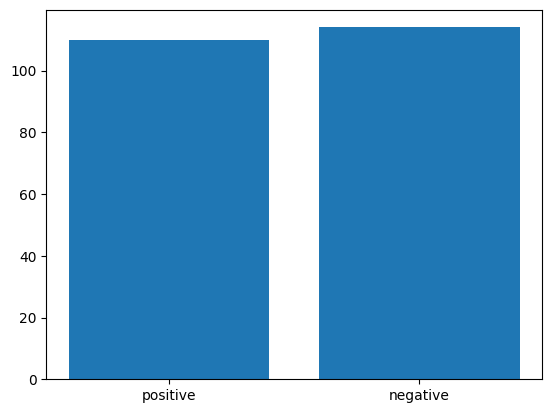

In [7]:
bins = range(3)
plt.hist(trainOutputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), labelNames)
plt.show()

### Pasul 3 - extragerea caracteristicilor

Reprezentare 1 -> BoW (Bag of Words)

Ce identifica in principal?
Prezenta cuvintelor in mesaj

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

# vom da fit numai pe setul de date de antrenament, pentru a crea vocabularul
# datele din setul de test vrem sa foloseasca acelasi vocabular, asa ca doar vom transforma mesajele pe baza vocabularului deja existent
trainFeatures1 = vectorizer.fit_transform(trainInputs)
testFeatures1 = vectorizer.transform(testInputs)


print("vocab size: ", len(vectorizer.vocabulary_),  " words")
print("traindata size: ", len(trainInputs), " messages")
print("trainFeatures shape: ", trainFeatures1.shape)

vocab size:  629  words
traindata size:  224  messages
trainFeatures shape:  (224, 629)


Reprezentare 2 -> TF - IDF (Term Frequency - Inverse Document Frequency)

Ce identifica in principal?
Importanta cuvintelor

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# indiferent de cate cuvinte distincte exista in setul de date, vocabularul le va retine pe primele 50 cele mai importante
vectorizer = TfidfVectorizer(max_features=50)

# vom da fit numai pe setul de date de antrenament, pentru a crea vocabularul
# datele din setul de test vrem sa foloseasca acelasi vocabular, asa ca doar vom transforma mesajele pe baza vocabularului deja existent
trainFeatures2 = vectorizer.fit_transform(trainInputs)
testFeatures2 = vectorizer.transform(testInputs)

# vocabbulary from the train data
print('vocab: ', vectorizer.get_feature_names_out()[:10])
print('features: ', trainFeatures2.toarray()[:3])

vocab:  ['air' 'all' 'and' 'are' 'as' 'at' 'bathroom' 'bed' 'clean' 'coffee']
features:  [[0.         0.         0.54294465 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.83976849
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.65236267 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0. 

Reprezentarea 3 -> word2vec

Ce identifica in principal?
Contextul si relatia dintre cuvinte

In [10]:
import gensim


# Google's pre-trained Word2Vec
crtDir =  os.getcwd()
modelPath = os.path.join(crtDir, '', 'GoogleNews-vectors-negative300.bin')

word2vecModel300 = gensim.models.KeyedVectors.load_word2vec_format(modelPath, binary=True)
print(word2vecModel300.most_similar('support'))
print("vec for house: ", word2vecModel300["house"])

[('supporting', 0.6251285076141357), ('suport', 0.6071150302886963), ('suppport', 0.6053199768066406), ('Support', 0.6044272780418396), ('supported', 0.6009396314620972), ('backing', 0.6007589101791382), ('supports', 0.5269277691841125), ('assistance', 0.5207138061523438), ('sup_port', 0.5192490220069885), ('supportive', 0.5110024809837341)]
vec for house:  [ 1.57226562e-01 -7.08007812e-02  5.39550781e-02 -1.89208984e-02
  9.17968750e-02  2.55126953e-02  7.37304688e-02 -5.68847656e-02
  1.79687500e-01  9.27734375e-02  9.03320312e-02 -4.12109375e-01
 -8.30078125e-02 -1.45507812e-01 -2.37304688e-01 -3.68652344e-02
  8.74023438e-02 -2.77099609e-02  1.13677979e-03  8.30078125e-02
  3.57421875e-01 -2.61718750e-01  7.47070312e-02 -8.10546875e-02
 -2.35595703e-02 -1.61132812e-01 -4.78515625e-02  1.85546875e-01
 -3.97949219e-02 -1.58203125e-01 -4.37011719e-02 -1.11328125e-01
 -1.05957031e-01  9.86328125e-02 -8.34960938e-02 -1.27929688e-01
 -1.39648438e-01 -1.86523438e-01 -5.71289062e-02 -1.176

In [11]:
def featureComputation(model, data):
    features = []
    phrases = [ phrase.split() for phrase in data]
    for phrase in phrases:
        # compute the embeddings of all the words from a phrase (words of more than 2 characters) known by the model
        vectors = [model[word] for word in phrase if (len(word) > 2) and (word in model.index_to_key)]
        if len(vectors) == 0:
            result = [0.0] * model.vector_size
        else:
            result = np.sum(vectors, axis=0) / len(vectors)
        features.append(result)
    return features

trainFeatures3 = featureComputation(word2vecModel300, trainInputs)
testFeatures3 = featureComputation(word2vecModel300, testInputs)

Extra caracteristici -> Parts of Speech (POS)

In [12]:
import spacy

# pentru importarea pachetului necesar
!python -m spacy download en_core_web_sm

# en - english
# core - general
# web - antrenat cu texte basic de pe web
# sm - small
nlp = spacy.load("en_core_web_sm")

def extract_pos_features(text):
    # se "proceseaza" mesajul -> practic determinarea partilor de vorbire
    doc = nlp(text)

    # creeaza un dictionar de frecventa (key -> partea de vb sub forma unui cod numeric; val -> nr de aparitii a partii de vb in mesaj)
    counts = doc.count_by(spacy.attrs.POS)

    # safety
    total = len(doc) if len(doc) > 0 else 1

    # Returnăm proporția (procentul) de POS-uri din acel mesaj
    return np.array([
        # in caz ca nu gaseste deloc o anumita parte de vb, o pune ca fiind 0 (in loc sa dea eroare)
        counts.get(92, 0) / total, # substantive
        counts.get(100, 0) / total, # verbe
        counts.get(84, 0) / total   # adjective
    ])

trainPOS = np.array([extract_pos_features(msg) for msg in trainInputs])
testPOS = np.array([extract_pos_features(msg) for msg in testInputs])

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 5.1 MB/s eta 0:00:03
     ------- -------------------------------- 2.4/12.8 MB 4.9 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 5.9 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 6.1 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 6.2 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 6.6 MB/s eta 0:00:01
     --------------------------------- ------ 10.7/12.8 MB 7.0 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 7.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Feature Fusion -> Word2Vec & POS

In [13]:
trainFeatures3 = np.hstack((trainFeatures3, trainPOS))
testFeatures3 = np.hstack((testFeatures3, testPOS))

### Pasul 4 - antrenarea modelului

In [14]:
from sklearn.neural_network import MLPClassifier

classifier = MLPClassifier(hidden_layer_sizes=(100,70,50),max_iter=1000)
classifier.fit(trainFeatures3, trainOutputs)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


### Pasul 5 - testarea modelului

In [15]:
computedTestOutputs = classifier.predict(testFeatures3)

# computedTestOutputs = [labelNames[value] for value in computedTestIndexes]
for i in range(0, len(testInputs)):
    print(testInputs[i], " -> computed output: ", computedTestOutputs[i], "; real output: ", testOutputs[i],"\n")

My room was immaculate and smelled so fresh and clean.  -> computed output:  positive ; real output:  positive 

Elevators tend to be slow...  -> computed output:  negative ; real output:  negative 

very loud construction noise out front of our window.  -> computed output:  negative ; real output:  negative 

Bathroom area large would have been nice with a bathtub.  -> computed output:  positive ; real output:  positive 

no way to lock the door.  -> computed output:  negative ; real output:  negative 

leading_AVL_Automatic aa facility  -> computed output:  positive ; real output:  positive 

Very spacious rooms, quiet and very comfortable.  -> computed output:  positive ; real output:  positive 

hotel was very Clean and had characters   -> computed output:  positive ; real output:  positive 

Room safe did not work.  -> computed output:  negative ; real output:  negative 

The phone in my room was not working.  -> computed output:  negative ; real output:  negative 

vital gym to a

### Pasul 6 -> Metrica de performanta

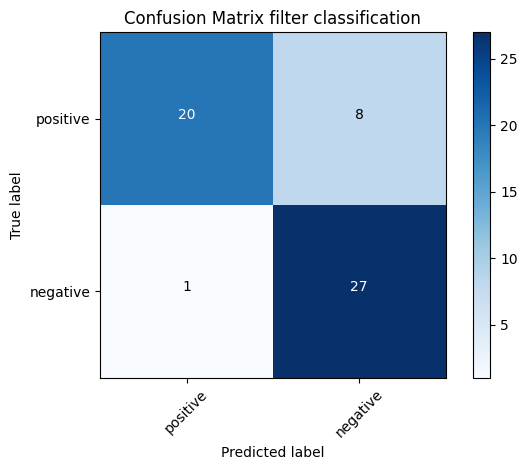

acc:  0.8392857142857143

precision: 
for positive:  0.9523809523809523
for negative:  0.7714285714285715

recall: 
for positive:  0.7142857142857143
for negative:  0.9642857142857143


In [16]:
import matplotlib.pyplot as plt

def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

def evalMultiClass(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix

    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix


acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), computedTestOutputs, labelNames)


plotConfusionMatrix(cm, labelNames, "filter classification")
print('acc: ', acc)

print('\nprecision: ')
print('for positive: ',prec['positive'])
print('for negative: ', prec['negative'])

print('\nrecall: ')
print('for positive: ',recall['positive'])
print('for negative: ', recall['negative'])